In [2]:
import os
import sys
import json

# set project root to current directory
PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [ ]:
# Set the NVIDIA API key as an environment variable
os.environ["NVIDIA_API_KEY"] = "nvapi-***-q"

In [4]:
# list files in the doc_a folder
doc_a_dir = "/Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/doc_a"
doc_a_files = os.listdir(doc_a_dir)

In [5]:
# initialize the CMSVS service
from api.services import CMSVSService 
service = CMSVSService()
config_name = "funsd_ner_config"

In [11]:
# create a folder to save results if it doesn't exist
output_dir = "/Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/predicted_truth"
os.makedirs(output_dir, exist_ok=True)

gt_dir = output_dir.replace("predicted_truth", "ground_truth")

In [7]:
# loop through doc_a files and get predictions from CMSVS, 
# then save the results in the predicted_truth folder with the same name as doc_a but with _pt.json extension
for doc_a_file_name in doc_a_files:
    print(f"Processing {doc_a_file_name}...")

    output_file = output_dir + "/" + doc_a_file_name.replace(".png", "_pt.json")
    # check if output file already exists, if yes then skip
    if os.path.exists(output_file):
        print(f"Output file {output_file} already exists, skipping...")
        continue

    doc_a_path = doc_a_dir + "/" + doc_a_file_name
    doc_b_path = doc_a_path.replace(".png", "_aug.png").replace("/doc_a/", "/doc_b/")

    res = service.validate_documents_gt(doc_b_path=doc_b_path, doc_a_path=doc_a_path, config_name=config_name, doc_a_name="doc_a", doc_b_name="doc_b")
    with open(output_file, "w") as f:
        _data = {"entities": res.dict()["entities"]}
        json.dump(_data, f, indent=4)
    print(f"Saved predictions to {output_file}")

Processing 87533049.png...


/var/folders/ps/jbtn6b3962jb6khx2x08bp4r0000gn/T/ipykernel_79526/2809251666.py:17: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  _data = {"entities": res.dict()["entities"]}


Saved predictions to /Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/predicted_truth/87533049_pt.json
Processing 01073843.png...
Saved predictions to /Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/predicted_truth/01073843_pt.json
Processing 0012529284.png...
Saved predictions to /Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/predicted_truth/0012529284_pt.json
Processing 00922237.png...
Saved predictions to /Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/predicted_truth/00922237_pt.json
Processing 93380187.png...
Saved predictions to /Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/predicted_truth/93380187_pt.json
Processing 00093726.png...
Saved predictions to /Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/predicted_truth/00093726_pt.json
Processing 87672097.png...
Saved predictions to /Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/predicted_truth/87672097_pt.json
Processing 00836244.png...
Saved predictions to /Users/mayank/Desktop/dsai/repo/ml5/datasets/FUNSD/

In [8]:
files = os.listdir(output_dir)
field_values = set()
for file in files:
    data = json.load(open(output_dir + "/" + file))
    for entity in data["entities"]:
        field_values.add(entity["validation_type"])
print("Unique field values in predictions:")
print(field_values)

Unique field values in predictions:
{'semantic_match', 'conflict', 'exact_match'}


In [ ]:
# generate a list of dictionaries for comparison of gt and pt values for each entity in each file
comparison_results = []
files = os.listdir(output_dir)
for file in files:
    _gt_data = json.load(open(gt_dir + "/" + file.replace("_pt.json", "_gt.json"))).get("entities", [])
    _pt_data = json.load(open(output_dir + "/" + file)).get("entities", [])

    gt_data = {entity["entity_name"]: entity for entity in _gt_data}
    pt_data = {entity["entity_name"]: entity for entity in _pt_data}
    all_entities = set(gt_data.keys()).union(set(pt_data.keys()))

    for entity_name in all_entities:
        gt_entity = gt_data.get(entity_name)
        pt_entity = pt_data.get(entity_name)

        normalised_gt_validation_type = "match" if gt_entity and gt_entity.get("validation_type") in ["semantic_match", "exact_match"] else gt_entity.get("validation_type") if gt_entity else None
        normalised_pt_validation_type = "match" if pt_entity and pt_entity.get("validation_type") in ["semantic_match", "exact_match"] else pt_entity.get("validation_type") if pt_entity else None        
        verdict = normalised_gt_validation_type == normalised_pt_validation_type
        # verdict : True means the prediction matches the ground truth, False means it doesn't match

        comparison_dict = {
            "file_name": file.replace("_pt.json", ""),
            "entity_name": entity_name,
            "gt_doc_a_value": gt_entity.get("doc_a_value") if gt_entity else None,
            "gt_doc_b_value": gt_entity.get("doc_b_value") if gt_entity else None,
            "gt_validation_type": gt_entity.get("validation_type") if gt_entity else None,
            "gt_validation_result": gt_entity.get("validation_result") if gt_entity else None,
            "gt_normalized_value": gt_entity.get("normalized_value") if gt_entity else None,
            "pt_doc_a_value": pt_entity.get("doc_a_value") if pt_entity else None,
            "pt_doc_b_value": pt_entity.get("doc_b_value") if pt_entity else None,
            "pt_validation_type": pt_entity.get("validation_type") if pt_entity else None,
            "pt_validation_result": pt_entity.get("validation_result") if pt_entity else None,
            "pt_normalized_value": pt_entity.get("normalized_value") if pt_entity else None,
            "normalised_gt_validation_type": normalised_gt_validation_type,
            "normalised_pt_validation_type": normalised_pt_validation_type,
            "verdict": verdict
        }
        comparison_results.append(comparison_dict.copy())
    


In [64]:
# convert comparison results to a dataframe for easier analysis
import pandas as pd
df = pd.DataFrame(comparison_results)

In [67]:
# filter the dataframe to only include rows where gt_validation_type is not None
# only process the entities where we have ground truth validation type, as those are the ones we can evaluate meaningfully
filtered_df = df[df["gt_validation_type"].notna()]
filtered_df.head()

,file_name,entity_name,gt_doc_a_value,gt_doc_b_value,gt_validation_type,gt_validation_result,gt_normalized_value,pt_doc_a_value,pt_doc_b_value,pt_validation_type,pt_validation_result,pt_normalized_value,normalised_gt_validation_type,normalised_pt_validation_type,verdict
1,0071032790,primary_signer_name,"R. S. Sprinkle, III","R. S. Sprinkle, Jr.",conflict,mismatch,NaN,"R. S. Sprinkle, III","R. S. Sprinkle, Jr.",conflict,mismatch,"r. s. sprinkle, iii",conflict,conflict,True
4,0071032790,document_date,"September 16, 1980",09/16/1980,semantic_match,match,"September 16, 1980","September 16, 1980",NaN,semantic_match,ineligible,"september 16, 1980",match,match,True
5,0071032790,document_title,PROJECT INITIATION FORM,project initiation form,exact_match,match,project initiation form,NaN,NaN,semantic_match,ineligible,NaN,match,match,True
10,0071032790,project_lead,E. P. Barbee,E. P. Barbee,exact_match,match,NaN,E. P. Barbee,E. P. Barbee,exact_match,match,e. p. barbee,match,match,True
14,0071032790,project_no_or_code,BTF,B.T.F.,semantic_match,match,NaN,BTF,B.T.F.,semantic_match,match,btf,match,match,True


In [82]:
filtered_df["gt_validation_type"].value_counts()

gt_validation_type
semantic_match    122
exact_match       118
conflict           39
Name: count, dtype: int64

In [80]:
filtered_df["verdict"].value_counts()

verdict
True     247
False     32
Name: count, dtype: int64

Overall Accuracy: 0.8853 (88.53%)

Classification Report (Precision, Recall, F1-Score):
-------------------------------------------------------
              precision    recall  f1-score   support

    conflict       0.56      0.79      0.66        39
       match       0.96      0.90      0.93       240

    accuracy                           0.89       279
   macro avg       0.76      0.85      0.80       279
weighted avg       0.91      0.89      0.89       279



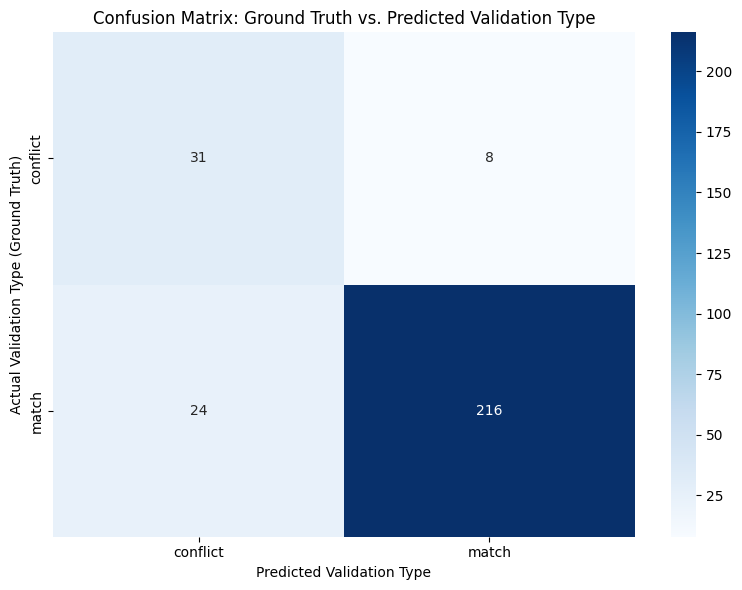

In [73]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data
# We fill NaNs in predictions with 'Missing' so sklearn can process them as a distinct incorrect class
y_true = filtered_df['normalised_gt_validation_type'].astype(str)
y_pred = filtered_df['normalised_pt_validation_type'].fillna('Missing').astype(str)

# 2. Overall Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)\n")

# 3. Detailed Classification Report (Precision, Recall, F1)
print("Classification Report (Precision, Recall, F1-Score):")
print("-" * 55)
print(classification_report(y_true, y_pred, zero_division=0))

# 4. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred, labels=y_true.unique())
cm_df = pd.DataFrame(cm, index=y_true.unique(), columns=y_true.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Ground Truth vs. Predicted Validation Type')
plt.ylabel('Actual Validation Type (Ground Truth)')
plt.xlabel('Predicted Validation Type')
plt.tight_layout()
plt.show()

=== OVERALL ACCURACY ===
Relaxed Accuracy (Verdict-based): 88.53%
Strict Accuracy (Category-based): 71.68%

=== CLASSIFICATION REPORT (Strict) ===
                precision    recall  f1-score   support

      conflict       0.56      0.79      0.66        39
   exact_match       0.88      0.56      0.68       118
semantic_match       0.69      0.84      0.76       122

      accuracy                           0.72       279
     macro avg       0.71      0.73      0.70       279
  weighted avg       0.75      0.72      0.71       279



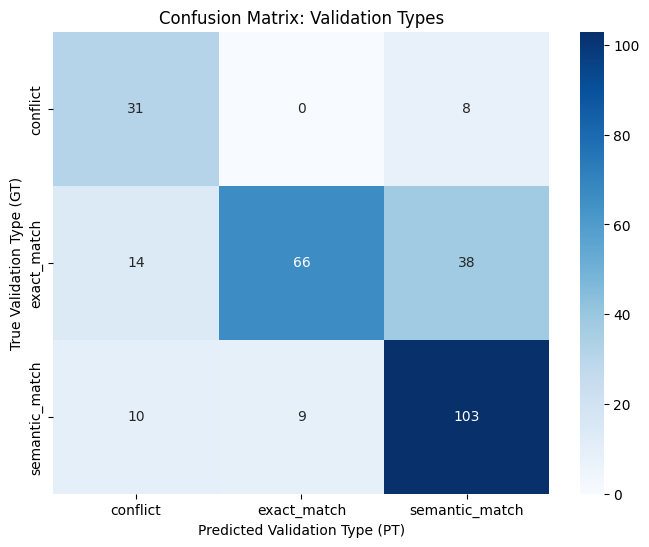

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we are dropping any remaining NaNs in the prediction column just in case
eval_df = filtered_df.dropna(subset=['gt_validation_type', 'pt_validation_type']).copy()

# ---------------------------------------------------------
# 1. ACCURACY METRICS
# ---------------------------------------------------------
# Relaxed Accuracy (Based on your custom 'verdict' logic)
verdict_counts = eval_df['verdict'].value_counts()
relaxed_accuracy = verdict_counts.get(True, 0) / len(eval_df)

# Strict Accuracy (Exact category match)
strict_accuracy = accuracy_score(eval_df['gt_validation_type'], eval_df['pt_validation_type'])

print("=== OVERALL ACCURACY ===")
print(f"Relaxed Accuracy (Verdict-based): {relaxed_accuracy:.2%}")
print(f"Strict Accuracy (Category-based): {strict_accuracy:.2%}\n")

# ---------------------------------------------------------
# 2. PRECISION, RECALL, & F1-SCORE
# ---------------------------------------------------------
print("=== CLASSIFICATION REPORT (Strict) ===")
# zero_division=0 prevents warnings if a class is completely missed
report = classification_report(
    eval_df['gt_validation_type'], 
    eval_df['pt_validation_type'], 
    zero_division=0
)
print(report)

# ---------------------------------------------------------
# 3. CONFUSION MATRIX VISUALIZATION
# ---------------------------------------------------------
cm = confusion_matrix(eval_df['gt_validation_type'], eval_df['pt_validation_type'])

# Get the unique labels dynamically to label the axes correctly
labels = sorted(eval_df['gt_validation_type'].unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix: Validation Types')
plt.xlabel('Predicted Validation Type (PT)')
plt.ylabel('True Validation Type (GT)')
plt.show()